In [1]:
# ── Config ──────────────────────────────────────────────────
import os; os.makedirs('output', exist_ok=True)

TUBULARITY_NPZ = 'output/FN1_01/tubularity_anchored.npz'
SOMA_NPZ       = 'output/FN1_01/soma.npz'
SOMA_JSON      = 'output/FN1_01/soma.json'
OUT_NPZ        = 'output/FN1_01/prep_riem.npz'
DOWNSAMPLE     = 2

# 볼륨 경계 마스킹 — 표면 노이즈가 FMM을 끌어당기는 것 방지
BORDER_PAD_Z_MIN   = 0     # 자동 감지 결과 최소값 (항상 최소 이만큼은 마스킹)
BORDER_PAD_Z_MAX   = 8     # 자동 감지 결과 상한 (과도한 마스킹 방지)
BORDER_ARTIFACT_RATIO = 1.5  # 엣지 슬라이스가 내부 대비 이 배율 이상이면 artifact로 판단
BORDER_PAD_XY      = 1     # XY 외곽 마스킹 (고정)

In [2]:
# ── Load + Downsample ───────────────────────────────────────
import numpy as np, json, gc, time
from scipy.ndimage import zoom, maximum_filter

t0 = time.time()

tub          = np.load(TUBULARITY_NPZ)
T            = tub['T_combined'].astype(np.float32)
radius       = tub['radius_map'].astype(np.float32)
orient_field = tub['orient_field'].astype(np.float32)
voxel_iso    = float(tub['voxel_iso'])
del tub; gc.collect()

soma_data = np.load(SOMA_NPZ)
soma_mask = soma_data['soma_mask']
del soma_data; gc.collect()

with open(SOMA_JSON) as f:
    soma = json.load(f)
soma_vox  = np.array(soma['centroid_vox'], dtype=np.float32)
soma_r_um = float(soma['radius_um'])

factor = 1.0 / DOWNSAMPLE

# T: max-pooling — 얇은 tube 신호 보존 (zoom 보간 시 0으로 소실됨)
T_maxpool = maximum_filter(T, size=DOWNSAMPLE)
T_down    = T_maxpool[::DOWNSAMPLE, ::DOWNSAMPLE, ::DOWNSAMPLE].astype(np.float32)
del T_maxpool; gc.collect()

radius_down    = zoom(radius,    factor, order=1).astype(np.float32)
soma_mask_down = zoom(soma_mask, factor, order=0).astype(bool)
del T, radius, soma_mask; gc.collect()

print('Downsampling orient_field...', flush=True)
vz = zoom(orient_field[..., 0], factor, order=1).astype(np.float32)
vy = zoom(orient_field[..., 1], factor, order=1).astype(np.float32)
vx = zoom(orient_field[..., 2], factor, order=1).astype(np.float32)
del orient_field; gc.collect()

norm = np.sqrt(vz**2 + vy**2 + vx**2) + 1e-8
vz /= norm; vy /= norm; vx /= norm
orient_down = np.stack([vz, vy, vx], axis=-1).astype(np.float16)
del vz, vy, vx, norm; gc.collect()

voxel_down    = voxel_iso * DOWNSAMPLE
soma_vox_down = (soma_vox * factor).astype(np.float32)
Zd, Yd, Xd   = T_down.shape

# ── BORDER_PAD_Z 자동 감지 ───────────────────────────────────
T_z = T_down.mean(axis=(1, 2))
mid_s = Zd // 4
mid_e = 3 * Zd // 4
interior_ref = np.percentile(T_z[mid_s:mid_e], 75)

def _detect_pad(profile, ref, ratio, max_pad):
    pad = 0
    for v in profile:
        if v > ref * ratio:
            pad += 1
        else:
            break
    return min(pad, max_pad)

pad_top = _detect_pad(T_z,       interior_ref, BORDER_ARTIFACT_RATIO, BORDER_PAD_Z_MAX)
pad_bot = _detect_pad(T_z[::-1], interior_ref, BORDER_ARTIFACT_RATIO, BORDER_PAD_Z_MAX)
BORDER_PAD_Z = max(pad_top, pad_bot, BORDER_PAD_Z_MIN)

# ── 경계 마스킹 적용 ─────────────────────────────────────────
if BORDER_PAD_Z > 0:
    T_down[:BORDER_PAD_Z]  = 0.0
    T_down[-BORDER_PAD_Z:] = 0.0
if BORDER_PAD_XY > 0:
    p = BORDER_PAD_XY
    T_down[:, :p, :]  = 0.0; T_down[:, -p:, :] = 0.0
    T_down[:, :, :p]  = 0.0; T_down[:, :, -p:] = 0.0

print(f'Border Z auto: top={pad_top}  bot={pad_bot}  → pad={BORDER_PAD_Z} vox'
      f'  (interior_ref={interior_ref:.3f}  ratio={BORDER_ARTIFACT_RATIO})')
print(f'Border XY: ±{BORDER_PAD_XY} vox')

print(f'T_down         : {T_down.shape}  voxel={voxel_down:.3f} µm  ({time.time()-t0:.1f}s)')
print(f'orient_down    : {orient_down.shape}  dtype={orient_down.dtype}')
print(f'soma_mask_down : {soma_mask_down.sum():,} voxels')
print(f'T range        : {T_down.min():.4f} – {T_down.max():.4f}')
print(f'soma_vox_down  : {soma_vox_down}  r={soma_r_um:.2f} µm')

Downsampling orient_field...
Border Z auto: top=0  bot=0  → pad=0 vox  (interior_ref=0.020  ratio=1.5)
Border XY: ±1 vox
T_down         : (532, 498, 495)  voxel=0.684 µm  (39.9s)
orient_down    : (532, 498, 495, 3)  dtype=float16
soma_mask_down : 23,782 voxels
T range        : 0.0000 – 1.0000
soma_vox_down  : [133.15895 233.69507 219.36577]  r=12.23 µm


orient norm (T>0.05): mean=0.0087  std=0.0928


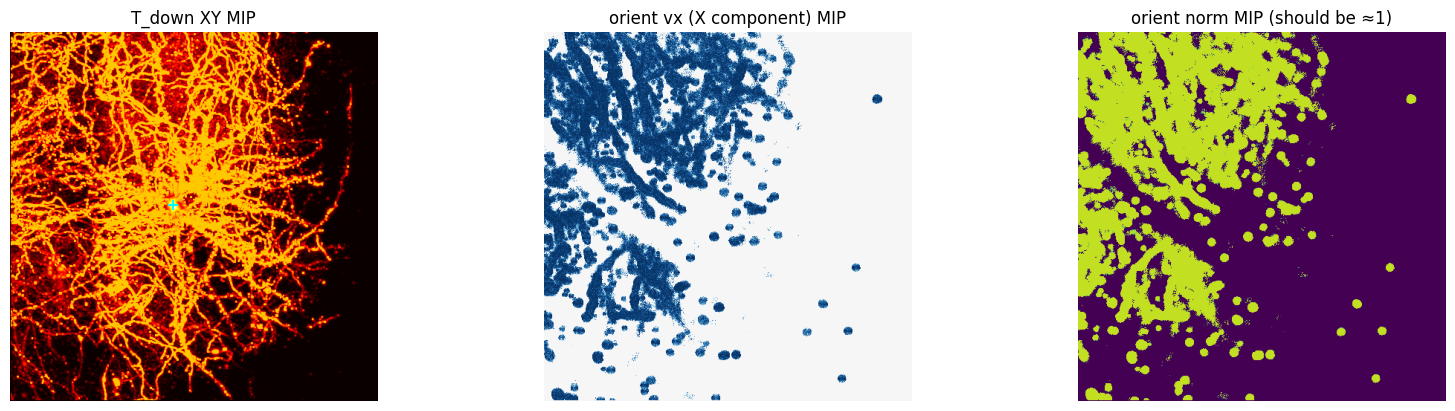

In [3]:
# ── CHECK ────────────────────────────────────────────────────
import matplotlib.pyplot as plt

# orient_field norm should be ≈1 everywhere (non-zero T)
of32   = orient_down.astype(np.float32)
v_norm = np.sqrt((of32**2).sum(axis=-1))
mask   = T_down > 0.05
print(f'orient norm (T>0.05): mean={v_norm[mask].mean():.4f}  std={v_norm[mask].std():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
axes[0].imshow(T_down.max(axis=0), cmap='hot', vmin=0, vmax=1)
axes[0].scatter([soma_vox_down[2]], [soma_vox_down[1]], c='cyan', s=60, marker='+', zorder=5)
axes[0].set_title('T_down XY MIP'); axes[0].axis('off')

# v_OOF direction: colour by vx (X component)
axes[1].imshow(of32[..., 2].max(axis=0), cmap='RdBu', vmin=-1, vmax=1)
axes[1].set_title('orient vx (X component) MIP'); axes[1].axis('off')

axes[2].imshow(v_norm.max(axis=0), cmap='viridis', vmin=0, vmax=1.1)
axes[2].set_title('orient norm MIP (should be ≈1)'); axes[2].axis('off')

plt.show()

EDT done in 10.2s
edt (foreground only):
  min=0.059  median=0.467  p99=2.137  max=4.708 µm


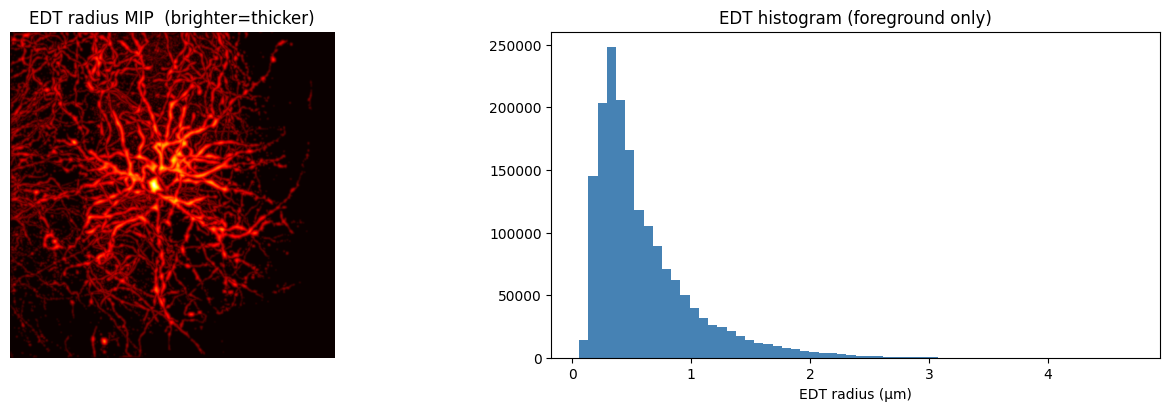

In [4]:
# ── EDT radius ───────────────────────────────────────────────
from scipy.ndimage import distance_transform_edt, gaussian_filter

EDT_THRESHOLD  = 0.20   # T_down 전경 기준 — 높을수록 전경 좁아져서 반경 줄어듦
EDT_SMOOTH_SIG = 1.0    # Gaussian sigma (voxel) — 낮출수록 EDT 덜 팽창
EDT_RADIUS_SCALE = 0.7  # EDT 반경 전체 스케일 (1.0=원본, <1.0=얇게)

t0 = time.time()
fg_mask = T_down > EDT_THRESHOLD

edt_raw  = distance_transform_edt(fg_mask).astype(np.float32) * voxel_down
edt_down = gaussian_filter(edt_raw, sigma=EDT_SMOOTH_SIG).astype(np.float32)
edt_down *= EDT_RADIUS_SCALE
del edt_raw; gc.collect()

fg_edt = edt_down[fg_mask]
print(f'EDT done in {time.time()-t0:.1f}s')
print(f'edt (foreground only):')
print(f'  min={fg_edt.min():.3f}  median={np.median(fg_edt):.3f}'
      f'  p99={np.percentile(fg_edt,99):.3f}  max={fg_edt.max():.3f} µm')
del fg_edt

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].imshow(edt_down.max(axis=0), cmap='hot')
axes[0].set_title('EDT radius MIP  (brighter=thicker)'); axes[0].axis('off')
axes[1].hist(edt_down[fg_mask].ravel(), bins=60, color='steelblue')
axes[1].set_xlabel('EDT radius (µm)'); axes[1].set_title('EDT histogram (foreground only)')
plt.show()

In [5]:
# ── Save ────────────────────────────────────────────────────
np.savez_compressed(OUT_NPZ,
    T_down         = T_down,
    radius_down    = radius_down,
    edt_down       = edt_down,
    orient_down    = orient_down,
    soma_mask_down = soma_mask_down,
    voxel_down     = np.float32(voxel_down),
    voxel_iso      = np.float32(voxel_iso),
    downsample     = np.int32(DOWNSAMPLE),
    soma_vox       = soma_vox,
    soma_vox_down  = soma_vox_down,
    soma_r_um      = np.float32(soma_r_um),
    border_pad_z   = np.int32(BORDER_PAD_Z),
    border_pad_xy  = np.int32(BORDER_PAD_XY),
)
print(f'Saved: {OUT_NPZ}')
print(f'  T_down         {T_down.shape}  float32')
print(f'  edt_down       {edt_down.shape}  float32  ← EDT radius')
print(f'  radius_down    {radius_down.shape}  float32  ← OOF radius')
print(f'  orient_down    {orient_down.shape}  float16')
print(f'  soma_mask_down {soma_mask_down.shape}  bool')
print(f'  voxel_down     {voxel_down:.3f} µm')
print(f'  border_pad_z   {BORDER_PAD_Z} vox')

Saved: output/FN1_01/prep_riem.npz
  T_down         (532, 498, 495)  float32
  edt_down       (532, 498, 495)  float32  ← EDT radius
  radius_down    (532, 498, 495)  float32  ← OOF radius
  orient_down    (532, 498, 495, 3)  float16
  soma_mask_down (532, 498, 495)  bool
  voxel_down     0.684 µm
  border_pad_z   0 vox
